------------------------------
PAIR: Patient Health Questionnaire 9 -> Work Related Burnout Score
Total samples: 147
------------------------------


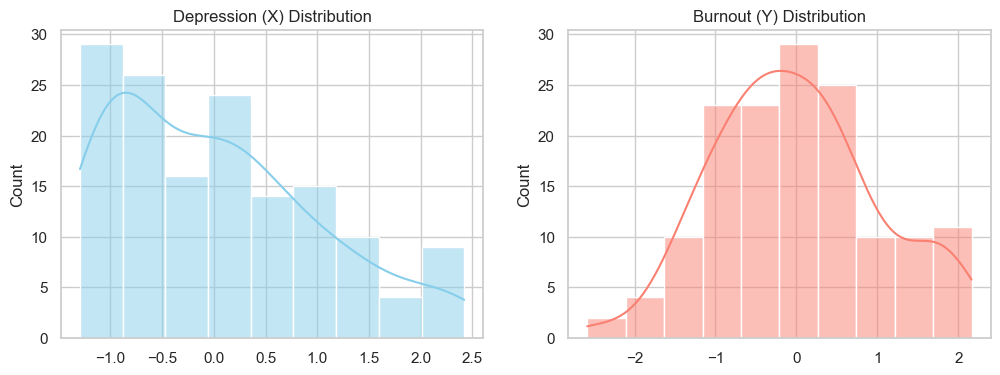

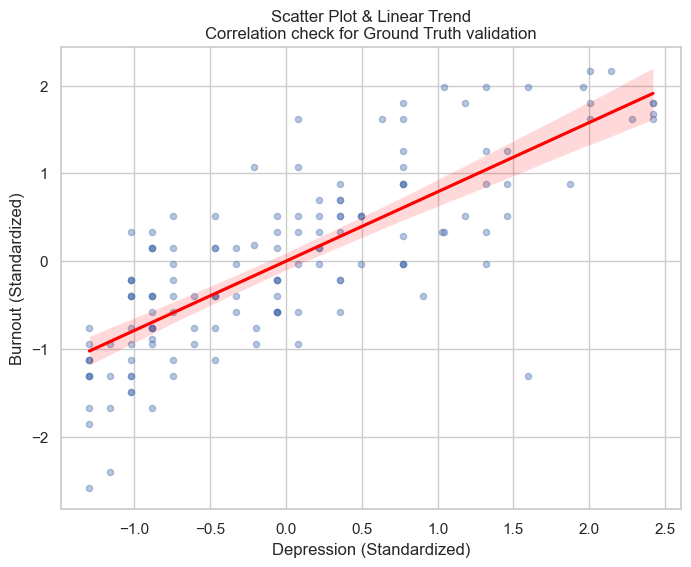


--- EDA STATISTICAL SUMMARY ---
Pearson Correlation (r): 0.7898
P-value: 1.3796e-32
Normality (Shapiro-Wilk p) - X: 0.0000
Normality (Shapiro-Wilk p) - Y: 0.0310
Note: If p < 0.05, data is non-Gaussian (Impacts IGCI base measure choice).


In [3]:
# Pair 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

# --- CONFIGURATION ---
FILE_PATH = r'C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Burnout\Copy of M1 Burnout Manuscript Data.xlsx'
X_COLUMN_NAME = 'Patient Health Questionnaire 9' # Depression
Y_COLUMN_NAME = 'Work Related Burnout Score'   # Burnout

# Set visual style for Open Science reporting
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 10, 'figure.figsize': (10, 6)})

def load_and_prepare_data(filepath, x_col, y_col):
    """Loads data, cleans it, and performs standardization for causal discovery."""
    try:
        data = pd.read_excel(filepath)
        # Select and clean the data
        df_pair = data[[x_col, y_col]].dropna()
        
        # Meta-data for transparency
        print("-" * 30)
        print(f"PAIR: {x_col} -> {y_col}")
        print(f"Total samples: {len(df_pair)}")
        print("-" * 30)
        
        # Standardize data: Required for ANM/IGCI to avoid scale bias
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_pair)
        
        return scaled_data[:, 0], scaled_data[:, 1], df_pair
    except Exception as e:
        print(f"Error: {e}")
        return None, None, None

# --- EXECUTION ---
X_data, Y_data, raw_df = load_and_prepare_data(FILE_PATH, X_COLUMN_NAME, Y_COLUMN_NAME)

if X_data is not None:
    # 1. DISTRIBUTION ANALYSIS
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(X_data, kde=True, ax=axes[0], color='skyblue').set_title('Depression (X) Distribution')
    sns.histplot(Y_data, kde=True, ax=axes[1], color='salmon').set_title('Burnout (Y) Distribution')
    plt.show()

    # 2. LINEARITY & CORRELATION
    # This represents the "experimental magnitude" mentioned in your report
    plt.figure(figsize=(8, 6))
    sns.regplot(x=X_data, y=Y_data, scatter_kws={'alpha':0.4, 's':20}, line_kws={'color':'red'})
    plt.title(f'Scatter Plot & Linear Trend\nCorrelation check for Ground Truth validation')
    plt.xlabel('Depression (Standardized)')
    plt.ylabel('Burnout (Standardized)')
    plt.show()

    # 3. STATISTICAL METRICS
    corr, p_val = stats.pearsonr(X_data, Y_data)
    shapiro_x = stats.shapiro(X_data)[1]
    shapiro_y = stats.shapiro(Y_data)[1]

    print("\n--- EDA STATISTICAL SUMMARY ---")
    print(f"Pearson Correlation (r): {corr:.4f}")
    print(f"P-value: {p_val:.4e}")
    print(f"Normality (Shapiro-Wilk p) - X: {shapiro_x:.4f}")
    print(f"Normality (Shapiro-Wilk p) - Y: {shapiro_y:.4f}")
    print("Note: If p < 0.05, data is non-Gaussian (Impacts IGCI base measure choice).")

else:
    print("Execution halted due to data loading error.")

✅ Data loaded. Samples: 205


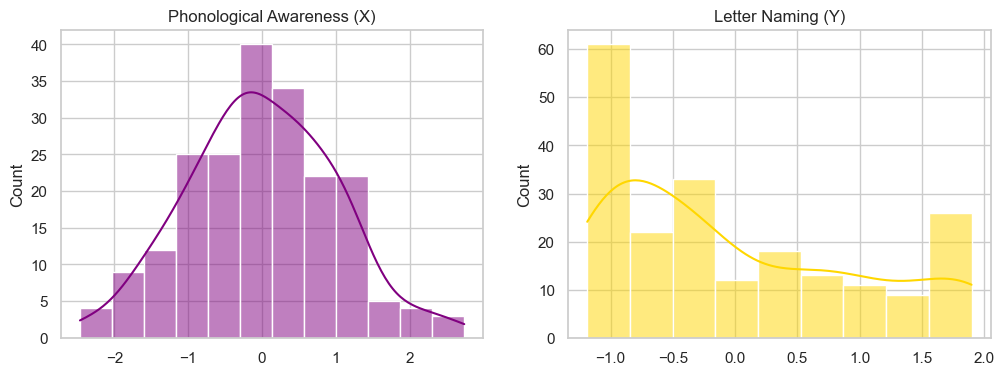

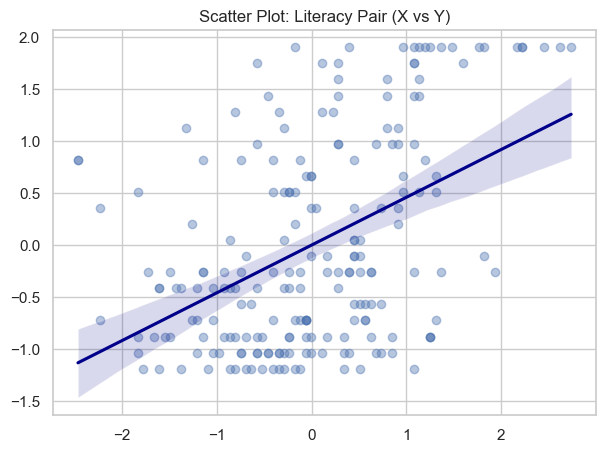


--- EDA STATS (Pair 2) ---
Pearson r: 0.4586 (p=4.68e-12)
Shapiro p (X): 0.7929
Shapiro p (Y): 0.0000


In [5]:
# Pair 2
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler

# --- 1. CONFIGURATION ---
DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Literacy_children\DeterminantsDyslexia_Exp3_data_final.csv"
SEPARATOR = ',' 
X_COLUMN_NAME = "Phonological_Awareness_Composite" 
Y_COLUMN_NAME = "T1_letter" 
PHONO_SUBTESTS = ['T1_rhyme', 'T1_rhymeprime', 'T1_audsynt', 'T1_phondel']

# --- 2. FUNCTION DEFINITION (MUST BE RUN FIRST) ---
def load_and_preprocess_literacy_data(file_path):
    """Loads data, calculates Composite score, and cleans data."""
    try:
        df = pd.read_csv(file_path, sep=SEPARATOR)
        # Calculate Composite
        df[X_COLUMN_NAME] = df[PHONO_SUBTESTS].sum(axis=1)
        # Select required columns and drop NaNs
        df_causal = df[[X_COLUMN_NAME, Y_COLUMN_NAME]].dropna()
        print(f"✅ Data loaded. Samples: {len(df_causal)}")
        return df_causal
    except Exception as e:
        print(f"❌ Error: {e}")
        return None

# --- 3. EXECUTION & EDA ---
df_literacy = load_and_preprocess_literacy_data(DATA_PATH)

if df_literacy is not None:
    # Standardize
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df_literacy)
    X_lit, Y_lit = scaled[:, 0], scaled[:, 1]

    # --- VISUALIZATION ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(X_lit, kde=True, ax=axes[0], color='purple').set_title('Phonological Awareness (X)')
    sns.histplot(Y_lit, kde=True, ax=axes[1], color='gold').set_title('Letter Naming (Y)')
    plt.show()

    plt.figure(figsize=(7, 5))
    sns.regplot(x=X_lit, y=Y_lit, scatter_kws={'alpha':0.4}, line_kws={'color':'darkblue'})
    plt.title('Scatter Plot: Literacy Pair (X vs Y)')
    plt.show()

    # --- STATS ---
    corr, p_val = stats.pearsonr(X_lit, Y_lit)
    print(f"\n--- EDA STATS (Pair 2) ---")
    print(f"Pearson r: {corr:.4f} (p={p_val:.2e})")
    print(f"Shapiro p (X): {stats.shapiro(X_lit)[1]:.4f}")
    print(f"Shapiro p (Y): {stats.shapiro(Y_lit)[1]:.4f}")

--- 1. Data Processing and Merging ---
Success! Merged sample size (N): 5489


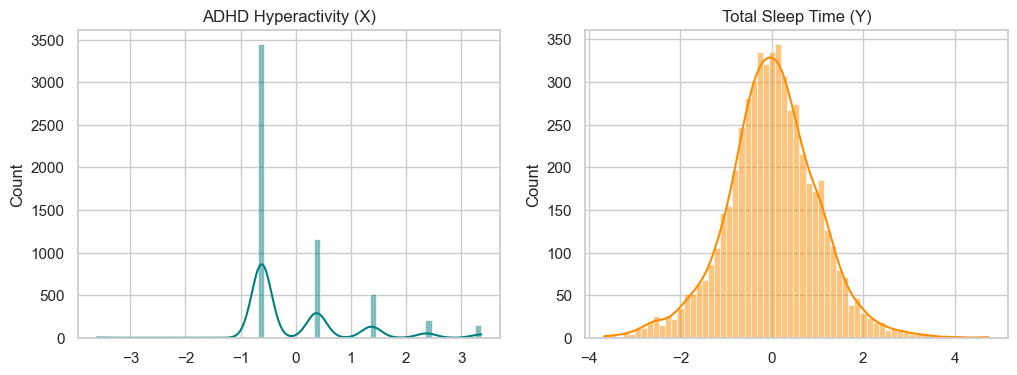

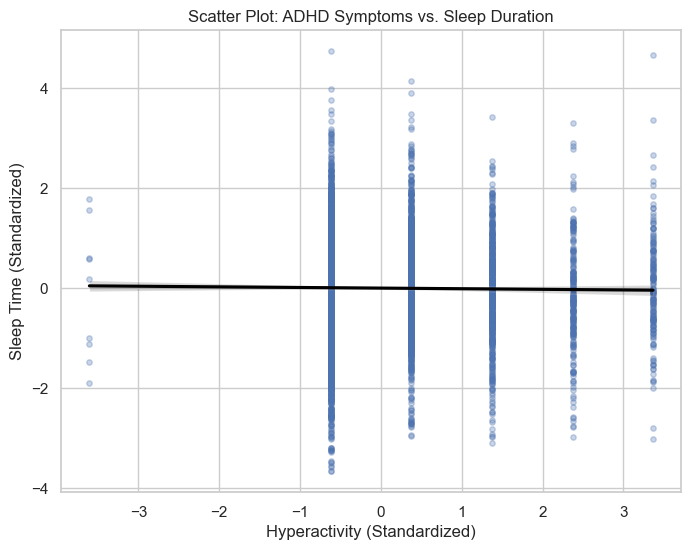


--- EDA STATISTICAL SUMMARY (Pair 3) ---
Pearson Correlation (r): -0.0124
P-value: 3.5674e-01
Normality Test (p) - ADHD: 0.0000
Normality Test (p) - Sleep: 0.0000
----------------------------------------


C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 5489.
  res = hypotest_fun_out(*samples, **kwds)


In [7]:
# Pair 3

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import os

# --- PART 1: Configuration ---
# Update these paths to your local TSV files
HYPERACTIVITY_DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Sleep_ADHD\Hyperactivity&Impulsivity\31622-0009-Data.tsv" 
SLEEPING_DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Sleep_ADHD\Sleep\31622-0011-Data.tsv" 

SEPARATOR = '\t' 
MERGE_KEY = 'IDNUM' 
X_SUBTESTS = ['P6B47', 'P6B48'] # ADHD Subtests
X_COLUMN_NAME = "Hyperactivity_Composite" 
Y_COLUMN_NAME = 'A6_NIGHTTST_MINS' # Total Sleep Time

# Set visual style for Open Science transparency
sns.set_theme(style="whitegrid")

# --- PART 2: Helper Functions ---

def find_robust_column(df, target_name):
    """Finds exact column name, ignoring case and spaces."""
    normalized_target = target_name.strip().upper()
    for col in df.columns:
        if col.strip().upper() == normalized_target:
            return col
    available_cols = [col for col in df.columns]
    raise KeyError(f"Column '{target_name}' not found. First 5: {available_cols[:5]}")

def create_merged_dataset(x_path, y_path, merge_key, x_subtests, y_col, sep):
    """Loads, merges, and prepares the ADHD-Sleep dataset."""
    print("--- 1. Data Processing and Merging ---")
    
    # Load raw TSV files
    df_x_raw = pd.read_csv(x_path, sep=sep)
    df_y_raw = pd.read_csv(y_path, sep=sep)

    # Resolve Column Names
    actual_merge_key_x = find_robust_column(df_x_raw, merge_key)
    actual_merge_key_y = find_robust_column(df_y_raw, merge_key)
    
    # Clean and Calculate ADHD Composite (X)
    for col in x_subtests:
        df_x_raw[col] = pd.to_numeric(df_x_raw[col], errors='coerce')
    df_x_raw[X_COLUMN_NAME] = df_x_raw[x_subtests].sum(axis=1)
    
    # Clean Sleep Column (Y)
    df_y_raw[y_col] = pd.to_numeric(df_y_raw[y_col], errors='coerce')
    
    # Prep for merge
    df_x = df_x_raw[[actual_merge_key_x, X_COLUMN_NAME]].rename(columns={actual_merge_key_x: merge_key})
    df_y = df_y_raw[[actual_merge_key_y, y_col]].rename(columns={actual_merge_key_y: merge_key})
    
    # Inner Join to find subjects present in both files
    merged_df = pd.merge(df_x, df_y, on=merge_key, how='inner').dropna()
    print(f"Success! Merged sample size (N): {len(merged_df)}")
    
    return merged_df

# --- PART 3: Execution & EDA ---

try:
    # 1. Process Data
    merged_df = create_merged_dataset(
        HYPERACTIVITY_DATA_PATH, 
        SLEEPING_DATA_PATH, 
        MERGE_KEY, 
        X_SUBTESTS, 
        Y_COLUMN_NAME, 
        SEPARATOR
    )
    
    # 2. Extract and Scale
    X_raw = merged_df[X_COLUMN_NAME].values.reshape(-1, 1)
    Y_raw = merged_df[Y_COLUMN_NAME].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw).flatten()
    Y_scaled = scaler.fit_transform(Y_raw).flatten()

    # 3. Distribution Visualizations
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(X_scaled, kde=True, ax=axes[0], color='teal').set_title('ADHD Hyperactivity (X)')
    sns.histplot(Y_scaled, kde=True, ax=axes[1], color='darkorange').set_title('Total Sleep Time (Y)')
    plt.show()

    # 4. Relationship Visualization
    plt.figure(figsize=(8, 6))
    sns.regplot(x=X_scaled, y=Y_scaled, scatter_kws={'alpha':0.3, 's':15}, line_kws={'color':'black'})
    plt.title('Scatter Plot: ADHD Symptoms vs. Sleep Duration')
    plt.xlabel('Hyperactivity (Standardized)')
    plt.ylabel('Sleep Time (Standardized)')
    plt.show()

    # 5. Statistical Profile
    corr, p_val = stats.pearsonr(X_scaled, Y_scaled)
    shapiro_x = stats.shapiro(X_scaled)[1]
    shapiro_y = stats.shapiro(Y_scaled)[1]

    print("\n--- EDA STATISTICAL SUMMARY (Pair 3) ---")
    print(f"Pearson Correlation (r): {corr:.4f}")
    print(f"P-value: {p_val:.4e}")
    print(f"Normality Test (p) - ADHD: {shapiro_x:.4f}")
    print(f"Normality Test (p) - Sleep: {shapiro_y:.4f}")
    print("-" * 40)

except Exception as e:
    print(f"CRITICAL ERROR: {e}")

--- Starting Pair 4 EDA: ASD Social Skills ---
Data loaded. Total rows in master file: 219
Filtered for Baseline. Final sample size (N): 69


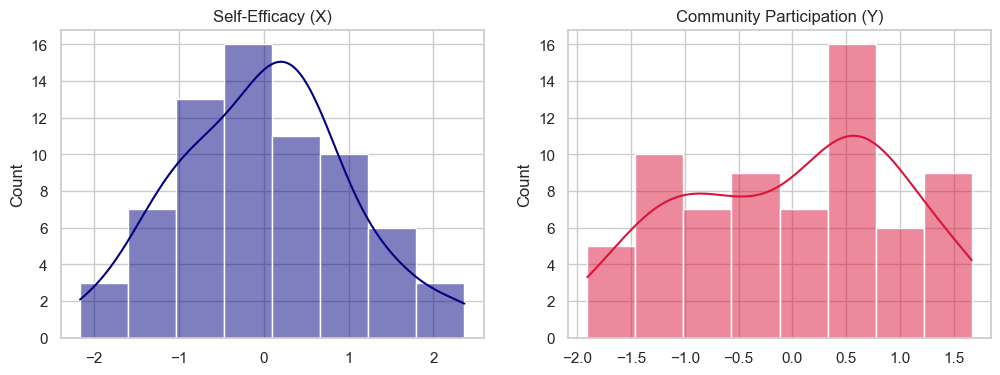

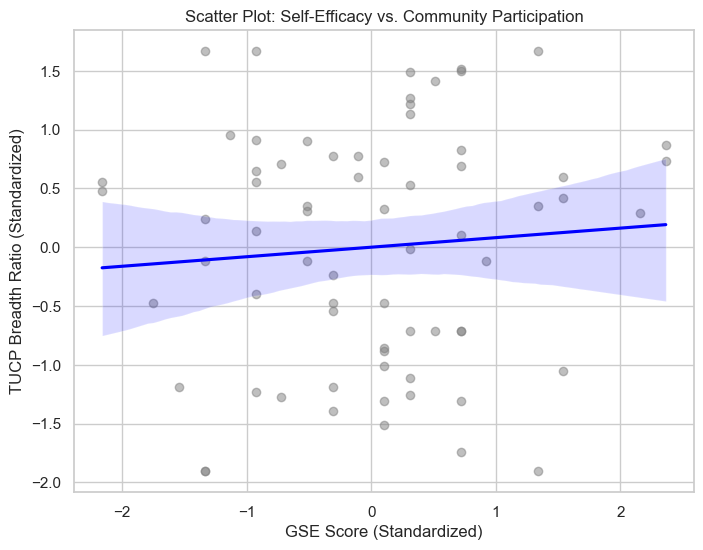


--- EDA STATISTICAL SUMMARY (Pair 4) ---
Pearson Correlation (r): 0.0811
P-value: 5.0763e-01
Normality Test (p) - Self-Efficacy: 0.3761
Normality Test (p) - Participation: 0.0194
----------------------------------------
Observation: Data is non-Gaussian. This favors the ANM algorithm.


In [8]:
# Pair 4

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import sys

# --- 1. CONFIGURATION ---
MASTER_DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Autism_Social_Skills\community_participation_data.tsv" 
SEPARATOR = '\t' 
TIME_COLUMN = 'time'
BASELINE_VALUE = 1.0 
X_COLUMN_NAME = "GSE_Score" # Self-Efficacy
Y_COLUMN_NAME = 'TUCP_Breadth_Ratio' # Social Skills/Participation

# --- 2. COMPLETE EDA & PREPARATION FUNCTION ---
def perform_pair4_eda():
    print("--- Starting Pair 4 EDA: ASD Social Skills ---")
    
    try:
        # Load Data
        df_raw = pd.read_csv(MASTER_DATA_PATH, sep=SEPARATOR)
        print(f"Data loaded. Total rows in master file: {len(df_raw)}")

        # Filter for Baseline (Time = 1.0)
        df_raw[TIME_COLUMN] = pd.to_numeric(df_raw[TIME_COLUMN], errors='coerce')
        filtered_df = df_raw[df_raw[TIME_COLUMN] == BASELINE_VALUE].copy()
        
        # Clean X and Y
        filtered_df[X_COLUMN_NAME] = pd.to_numeric(filtered_df[X_COLUMN_NAME], errors='coerce')
        filtered_df[Y_COLUMN_NAME] = pd.to_numeric(filtered_df[Y_COLUMN_NAME], errors='coerce')
        
        analysis_df = filtered_df[[X_COLUMN_NAME, Y_COLUMN_NAME]].dropna()
        n_samples = len(analysis_df)
        print(f"Filtered for Baseline. Final sample size (N): {n_samples}")

        if n_samples < 5:
            print("Error: Not enough data points after filtering.")
            return

        # Scaling for Causal Discovery
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(analysis_df)
        X_scaled = scaled_data[:, 0]
        Y_scaled = scaled_data[:, 1]

        # --- 3. VISUALIZATIONS ---
        # Distribution Checks
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(X_scaled, kde=True, ax=axes[0], color='navy').set_title('Self-Efficacy (X)')
        sns.histplot(Y_scaled, kde=True, ax=axes[1], color='crimson').set_title('Community Participation (Y)')
        plt.show()

        # Scatter plot for Linear Trend
        plt.figure(figsize=(8, 6))
        sns.regplot(x=X_scaled, y=Y_scaled, scatter_kws={'alpha':0.5, 'color':'gray'}, line_kws={'color':'blue'})
        plt.title('Scatter Plot: Self-Efficacy vs. Community Participation')
        plt.xlabel('GSE Score (Standardized)')
        plt.ylabel('TUCP Breadth Ratio (Standardized)')
        plt.show()

        # --- 4. STATISTICAL SUMMARY ---
        r, p_val = stats.pearsonr(X_scaled, Y_scaled)
        shapiro_x = stats.shapiro(X_scaled)[1]
        shapiro_y = stats.shapiro(Y_scaled)[1]

        print("\n--- EDA STATISTICAL SUMMARY (Pair 4) ---")
        print(f"Pearson Correlation (r): {r:.4f}")
        print(f"P-value: {p_val:.4e}")
        print(f"Normality Test (p) - Self-Efficacy: {shapiro_x:.4f}")
        print(f"Normality Test (p) - Participation: {shapiro_y:.4f}")
        print("-" * 40)
        
        if shapiro_x < 0.05 or shapiro_y < 0.05:
            print("Observation: Data is non-Gaussian. This favors the ANM algorithm.")
        else:
            print("Observation: Data is Gaussian. May cause symmetry issues for ANM.")

    except Exception as e:
        print(f"EDA failed: {e}")

# Run the analysis
if __name__ == "__main__":
    perform_pair4_eda()

--- Starting Pair 5 EDA: Motivation & Learning Outcomes ---
Data loaded. Initial rows: 497
Sample size after cleaning (N): 497


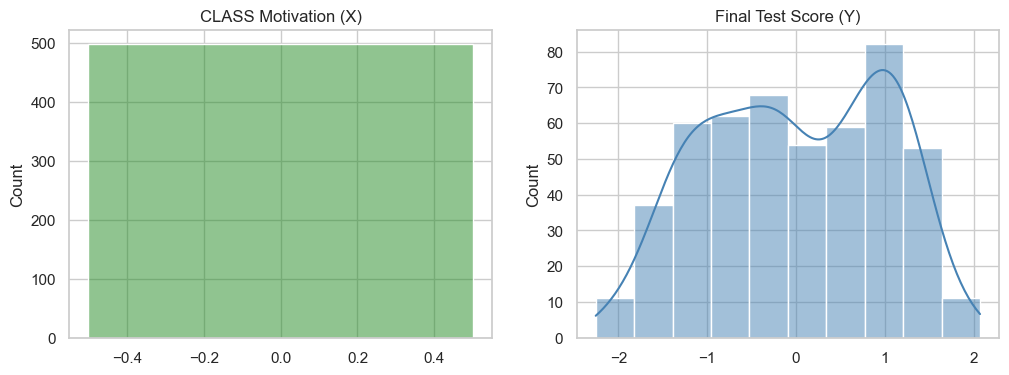

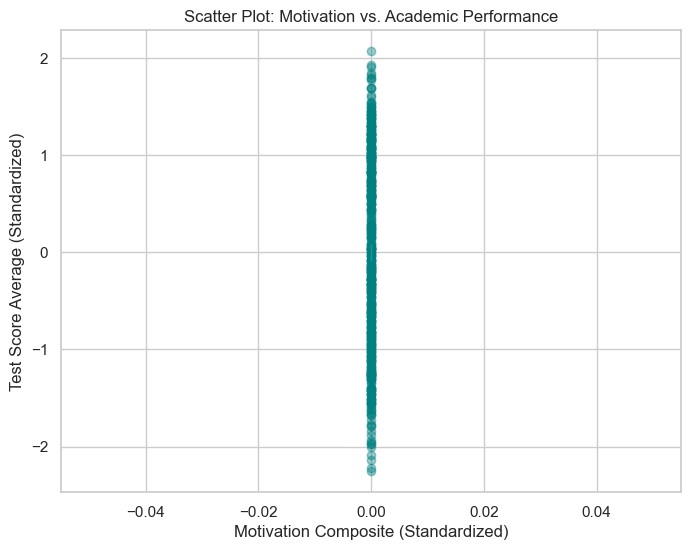


--- EDA STATISTICAL SUMMARY (Pair 5) ---
Pearson Correlation (r): nan
P-value: nan
Normality Test (p) - Motivation: 1.0000
Normality Test (p) - Test Score: 0.0000
----------------------------------------


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_43832\2510630902.py:91: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p_val = stats.pearsonr(X_scaled, Y_scaled)
C:\Users\Lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


In [9]:
# Pair 5

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import sys

# --- PART 1: CONFIGURATION ---
DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\5E_Science_outcomes\SPHERE_dataset.csv" 
SEPARATOR = ',' 
X_PREFIX = 'CLASS' 
X_COLUMN_NAME = "CLASS_Motivation_Composite" 
Y_SUBTESTS = ['FINTEST1', 'FINTEST2']
Y_COLUMN_NAME = 'FINTEST_Average'
SCORE_MAP = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5}
MAX_CLASS_ITEMS = 42 

# --- PART 2: DATA PROCESSING FUNCTIONS ---

def find_robust_column(df, target_name):
    normalized_target = target_name.strip().upper()
    for col in df.columns:
        if col.strip().upper() == normalized_target:
            return col 
    raise KeyError(f"Column '{target_name}' not found.")

def create_proxies(df_raw, score_map, max_class_items):
    class_cols = [f'{X_PREFIX}{i}' for i in range(1, max_class_items + 1) if f'{X_PREFIX}{i}' in df_raw.columns]
    
    df_proc = df_raw.copy()
    # Map CLASS items (A-E to 1-5)
    for col in class_cols:
        df_proc[col] = df_proc[col].astype(str).str.strip().str.upper().map(score_map)
    
    # Calculate X (Motivation Sum) and Y (Test Average)
    df_proc[X_COLUMN_NAME] = df_proc[class_cols].fillna(0).sum(axis=1)
    
    y1 = find_robust_column(df_proc, Y_SUBTESTS[0])
    y2 = find_robust_column(df_proc, Y_SUBTESTS[1])
    df_proc[y1] = pd.to_numeric(df_proc[y1], errors='coerce')
    df_proc[y2] = pd.to_numeric(df_proc[y2], errors='coerce')
    df_proc[Y_COLUMN_NAME] = df_proc[[y1, y2]].mean(axis=1)
    
    return df_proc

# --- PART 3: MAIN EDA EXECUTION ---

def run_pair5_eda():
    print("--- Starting Pair 5 EDA: Motivation & Learning Outcomes ---")
    
    try:
        # Load with encoding fallback
        try:
            df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding='utf-8')
        except UnicodeDecodeError:
            df_raw = pd.read_csv(DATA_PATH, sep=SEPARATOR, encoding='latin-1')
            
        print(f"Data loaded. Initial rows: {len(df_raw)}")

        # Process Proxies
        df_processed = create_proxies(df_raw, SCORE_MAP, MAX_CLASS_ITEMS)
        
        # Drop NaNs for the final analysis set
        analysis_df = df_processed[[X_COLUMN_NAME, Y_COLUMN_NAME]].dropna()
        n_samples = len(analysis_df)
        print(f"Sample size after cleaning (N): {n_samples}")

        # Scaling
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(analysis_df)
        X_scaled = scaled_data[:, 0]
        Y_scaled = scaled_data[:, 1]

        # --- VISUALIZATION ---
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        sns.histplot(X_scaled, kde=True, ax=axes[0], color='forestgreen').set_title('CLASS Motivation (X)')
        sns.histplot(Y_scaled, kde=True, ax=axes[1], color='steelblue').set_title('Final Test Score (Y)')
        plt.show()

        plt.figure(figsize=(8, 6))
        sns.regplot(x=X_scaled, y=Y_scaled, scatter_kws={'alpha':0.4, 'color':'teal'}, line_kws={'color':'red'})
        plt.title('Scatter Plot: Motivation vs. Academic Performance')
        plt.xlabel('Motivation Composite (Standardized)')
        plt.ylabel('Test Score Average (Standardized)')
        plt.show()

        # --- STATS ---
        r, p_val = stats.pearsonr(X_scaled, Y_scaled)
        shapiro_x = stats.shapiro(X_scaled)[1]
        shapiro_y = stats.shapiro(Y_scaled)[1]

        print("\n--- EDA STATISTICAL SUMMARY (Pair 5) ---")
        print(f"Pearson Correlation (r): {r:.4f}")
        print(f"P-value: {p_val:.4e}")
        print(f"Normality Test (p) - Motivation: {shapiro_x:.4f}")
        print(f"Normality Test (p) - Test Score: {shapiro_y:.4f}")
        print("-" * 40)

    except Exception as e:
        print(f"EDA Failed: {e}")

if __name__ == "__main__":
    run_pair5_eda()

--- Starting EDA for Pairs 6-11 (NSCH FASD Subgroup) ---
Master dataset loaded. Total records: 51375
FASD Subgroup identified. N = 226

Processing Pair 6: Provider Comm -> Memory...
--- Pair 6: Provider Comm -> Memory Results ---
Samples: 102
Correlation (r): -0.1587 (p=1.1102e-01)
Normality X (p): 0.0000 | Normality Y (p): 0.0000


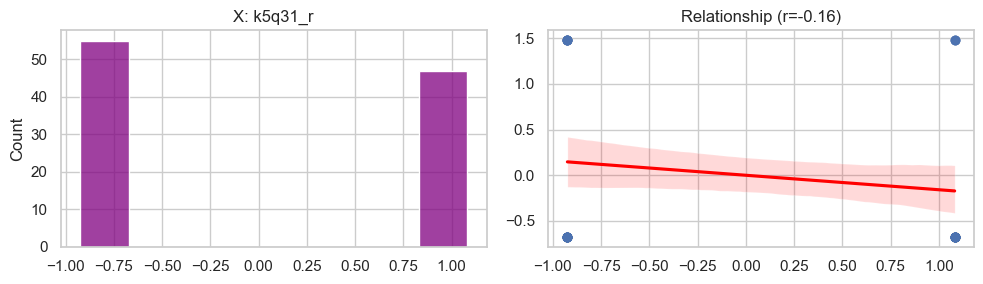


Processing Pair 7: PosChoice -> Conduct...
--- Pair 7: PosChoice -> Conduct Results ---
Samples: 102
Correlation (r): 0.1449 (p=1.4608e-01)
Normality X (p): 0.0000 | Normality Y (p): 0.0000


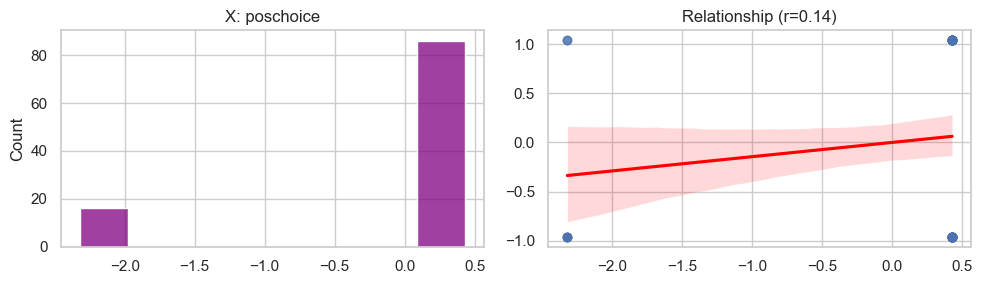


Processing Pair 8: Meds -> Emotional Control...
--- Pair 8: Meds -> Emotional Control Results ---
Samples: 183
Correlation (r): -0.4349 (p=7.6721e-10)
Normality X (p): 0.0000 | Normality Y (p): 0.0000


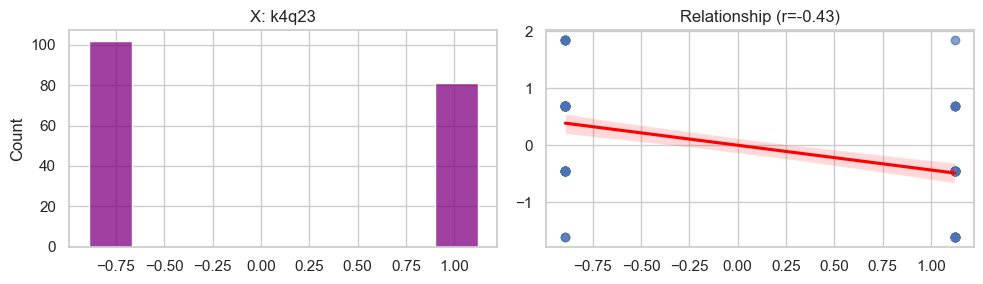


Processing Pair 9: Speech Support -> Attention...
--- Pair 9: Speech Support -> Attention Results ---
Samples: 29
Correlation (r): -0.5117 (p=4.5510e-03)
Normality X (p): 0.0000 | Normality Y (p): 0.0000


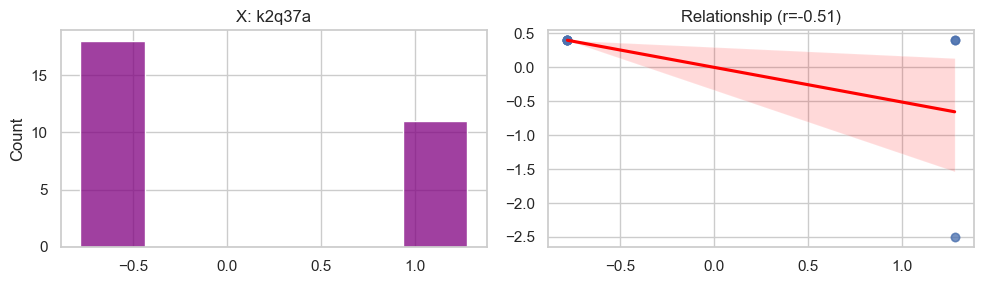


Processing Pair 10: ADHD Support -> Inhibition...
--- Pair 10: ADHD Support -> Inhibition Results ---
Samples: 185
Correlation (r): -0.5289 (p=1.0062e-14)
Normality X (p): 0.0000 | Normality Y (p): 0.0000


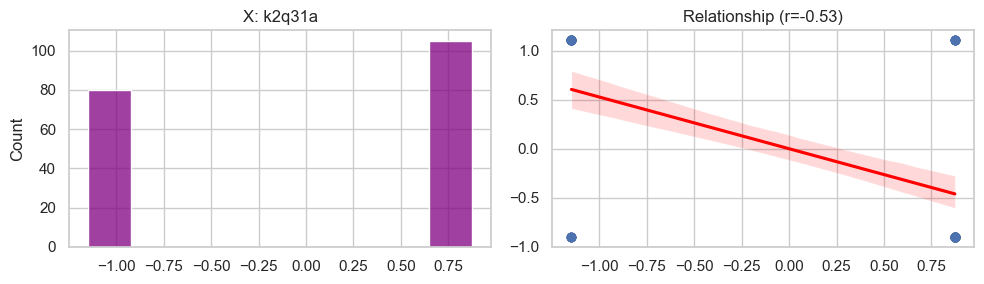


Processing Pair 11: LD Status -> Storytelling...
Skipping Pair 11: LD Status -> Storytelling: Sample size too small (N=6)


In [10]:
# Pairs 6 to 11 

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
import sys

# --- CONFIGURATION ---
DATA_PATH = r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\6_pairs_for_zero_effect\nsch_2024e_topical.dta"

def perform_comprehensive_eda():
    print("--- Starting EDA for Pairs 6-11 (NSCH FASD Subgroup) ---")
    
    try:
        # 1. Load Data with all required columns for Pairs 6-11
        cols_to_load = [
            'fasd', 'recevalfasd', 'k5q31_r', 'memorycond', 'k2q30a', 'k6q71_r',
            'poschoice', 'k2q34a', 'k4q23', 'directions2', 'k7q85_r', 'directions',
            'understand2', 'k2q37a', 'k2q31a', 'k2q30c', 'tellstory'
        ]
        
        # Load Stata file
        df = pd.read_stata(DATA_PATH, columns=cols_to_load)
        print(f"Master dataset loaded. Total records: {len(df)}")

        # 2. Filter for FASD Subgroup (The 'Cause' population)
        # We include children ever diagnosed or currently having FASD
        df_fasd = df[
            (df['recevalfasd'].isin([1, 'Yes'])) | 
            (df['fasd'].isin([1, 'Yes']))
        ].copy()
        
        print(f"FASD Subgroup identified. N = {len(df_fasd)}")
        
        if len(df_fasd) == 0:
            print("Error: FASD subgroup is empty. Check column values.")
            return

        # 3. Define the Pairs and their Recoding Logic
        # Format: (Name, X_col, Y_col, X_map, Y_map)
        pairs_config = [
            ("Pair 6: Provider Comm -> Memory", 'k5q31_r', 'memorycond', {1:1, 2:0}, {1:0, 2:1}),
            ("Pair 7: PosChoice -> Conduct", 'poschoice', 'k2q34a', {1:1, 2:0}, {1:0, 2:1}),
            ("Pair 8: Meds -> Emotional Control", 'k4q23', 'k7q85_r', {1:1, 2:0}, {1:4, 2:3, 3:2, 4:1, 5:0}),
            ("Pair 9: Speech Support -> Attention", 'k2q37a', 'directions', {1:1, 2:0}, {1:4, 2:3, 3:2, 4:1}),
            ("Pair 10: ADHD Support -> Inhibition", 'k2q31a', 'memorycond', {1:1, 2:0}, {1:0, 2:1}),
            ("Pair 11: LD Status -> Storytelling", 'k2q30c', 'tellstory', {1:3, 2:2, 3:1}, {1:1, 2:0})
        ]

        # 4. Loop through each pair to generate stats and plots
        for name, x_raw, y_raw, x_map, y_map in pairs_config:
            print(f"\nProcessing {name}...")
            
            # Create a clean copy for the pair
            temp_df = df_fasd[[x_raw, y_raw]].copy()
            
            # Apply Recoding
            temp_df['X'] = temp_df[x_raw].map(x_map)
            temp_df['Y'] = temp_df[y_raw].map(y_map)
            
            # Clean NaNs
            analysis_df = temp_df[['X', 'Y']].dropna()
            n = len(analysis_df)
            
            if n < 10:
                print(f"Skipping {name}: Sample size too small (N={n})")
                continue

            # Scaling
            scaler = StandardScaler()
            scaled = scaler.fit_transform(analysis_df)
            X_scaled = scaled[:, 0]
            Y_scaled = scaled[:, 1]

            # Statistics
            r, p_val = stats.pearsonr(X_scaled, Y_scaled)
            norm_x = stats.shapiro(X_scaled)[1] if n > 3 else 1
            norm_y = stats.shapiro(Y_scaled)[1] if n > 3 else 1

            print(f"--- {name} Results ---")
            print(f"Samples: {n}")
            print(f"Correlation (r): {r:.4f} (p={p_val:.4e})")
            print(f"Normality X (p): {norm_x:.4f} | Normality Y (p): {norm_y:.4f}")

            # Plotting
            fig, ax = plt.subplots(1, 2, figsize=(10, 3))
            sns.histplot(X_scaled, kde=False, ax=ax[0], color='purple').set_title(f'X: {x_raw}')
            sns.regplot(x=X_scaled, y=Y_scaled, ax=ax[1], scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
            ax[1].set_title(f'Relationship (r={r:.2f})')
            plt.tight_layout()
            plt.show()

    except Exception as e:
        print(f"EDA Process failed: {e}")

if __name__ == "__main__":
    perform_comprehensive_eda()

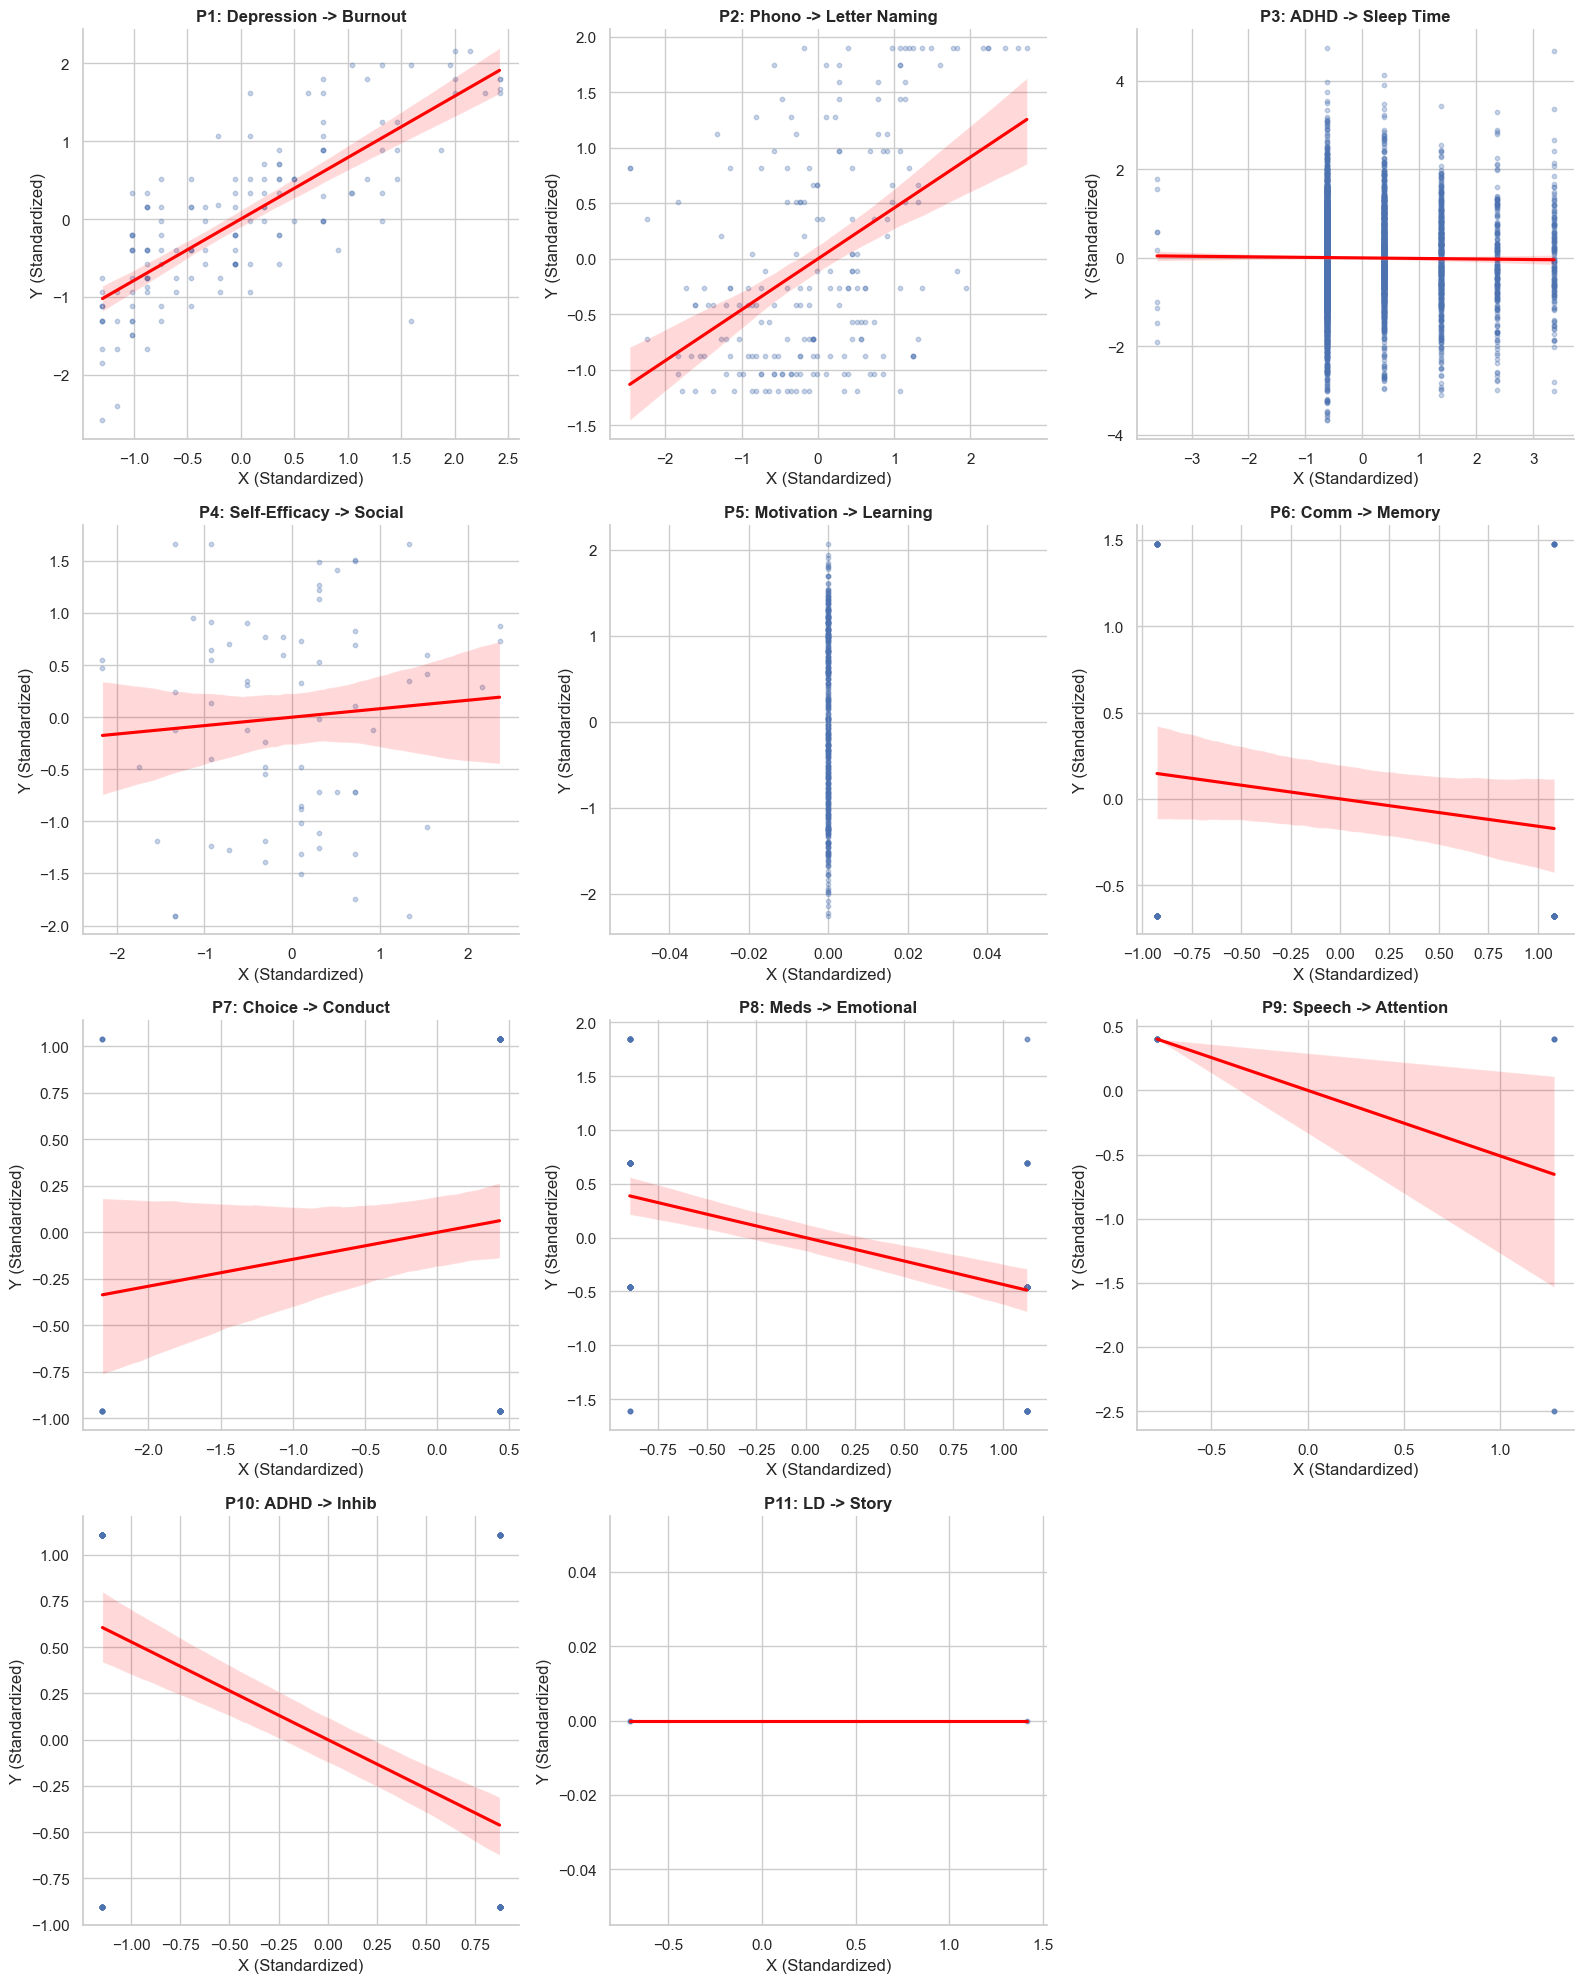

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# --- 1. SETUP: RE-INDEXING DATA SOURCES ---
sources = [
    {"path": r'C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Burnout\Copy of M1 Burnout Manuscript Data.xlsx', 
     "type": "excel", "x": 'Patient Health Questionnaire 9', "y": 'Work Related Burnout Score', "title": "P1: Depression -> Burnout"},
    
    {"path": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Literacy_children\DeterminantsDyslexia_Exp3_data_final.csv", 
     "type": "csv", "x": "Phonological_Awareness_Composite", "y": "T1_letter", "title": "P2: Phono -> Letter Naming", "sep": ","},
    
    {"path_x": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Sleep_ADHD\Hyperactivity&Impulsivity\31622-0009-Data.tsv",
     "path_y": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Sleep_ADHD\Sleep\31622-0011-Data.tsv", 
     "type": "adhd_merge", "title": "P3: ADHD -> Sleep Time"},
    
    {"path": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\Autism_Social_Skills\community_participation_data.tsv", 
     "type": "tsv", "x": "GSE_Score", "y": "TUCP_Breadth_Ratio", "title": "P4: Self-Efficacy -> Social"},
    
    {"path": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\5E_Science_outcomes\SPHERE_dataset.csv", 
     "type": "csv_latin", "x": "CLASS_Motivation_Composite", "y": "FINTEST_Average", "title": "P5: Motivation -> Learning"},

    {"path": r"C:\Users\Lenovo\Desktop\Licenta\Non_exp_Data\6_pairs_for_zero_effect\nsch_2024e_topical.dta", 
     "type": "nsch_group", "title": "P6-P11: NSCH Benchmarks"}
]

processed_pairs = []
scaler = StandardScaler()

# --- 2. AUTOMATED EXTRACTION LOOP ---
for src in sources:
    try:
        if src["type"] == "excel":
            df = pd.read_excel(src["path"])[[src["x"], src["y"]]].dropna()
            scaled = scaler.fit_transform(df)
            processed_pairs.append({"x": scaled[:,0], "y": scaled[:,1], "title": src["title"]})
            
        elif src["type"] == "csv":
            df = pd.read_csv(src["path"], sep=src["sep"])
            # Handling potential spaces in literacy columns
            for col in ['T1_rhyme', 'T1_rhymeprime', 'T1_audsynt', 'T1_phondel']:
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
            df[src["x"]] = df[['T1_rhyme', 'T1_rhymeprime', 'T1_audsynt', 'T1_phondel']].sum(axis=1)
            df = df[[src["x"], src["y"]]].dropna()
            scaled = scaler.fit_transform(df)
            processed_pairs.append({"x": scaled[:,0], "y": scaled[:,1], "title": src["title"]})

        elif src["type"] == "adhd_merge":
            df_x = pd.read_csv(src["path_x"], sep='\t')
            df_y = pd.read_csv(src["path_y"], sep='\t')
            # FIX: Convert to numeric and coerce errors for string-to-float failure
            for col in ['P6B47', 'P6B48']:
                df_x[col] = pd.to_numeric(df_x[col], errors='coerce').fillna(0)
            df_x['X'] = df_x[['P6B47', 'P6B48']].sum(axis=1)
            
            df_y['A6_NIGHTTST_MINS'] = pd.to_numeric(df_y['A6_NIGHTTST_MINS'], errors='coerce')
            
            merged = pd.merge(df_x[['IDNUM', 'X']], df_y[['IDNUM', 'A6_NIGHTTST_MINS']], on='IDNUM').dropna()
            scaled = scaler.fit_transform(merged[['X', 'A6_NIGHTTST_MINS']])
            processed_pairs.append({"x": scaled[:,0], "y": scaled[:,1], "title": src["title"]})

        elif src["type"] == "tsv":
            df = pd.read_csv(src["path"], sep='\t')
            df['time'] = pd.to_numeric(df['time'], errors='coerce')
            df = df[df['time'] == 1.0][[src["x"], src["y"]]].dropna()
            scaled = scaler.fit_transform(df)
            processed_pairs.append({"x": scaled[:,0], "y": scaled[:,1], "title": src["title"]})

        elif src["type"] == "csv_latin":
            df = pd.read_csv(src["path"], encoding='latin-1')
            cols = [f'CLASS{i}' for i in range(1, 43) if f'CLASS{i}' in df.columns]
            df['X'] = df[cols].fillna(0).apply(lambda x: x.astype(str).str.strip().str.upper().map({'A':1,'B':2,'C':3,'D':4,'E':5})).sum(axis=1)
            df['Y'] = pd.to_numeric(df['FINTEST1'], errors='coerce')/2 + pd.to_numeric(df['FINTEST2'], errors='coerce')/2 # Safe mean
            df = df[['X', 'Y']].dropna()
            scaled = scaler.fit_transform(df)
            processed_pairs.append({"x": scaled[:,0], "y": scaled[:,1], "title": src["title"]})

        elif src["type"] == "nsch_group":
            df = pd.read_stata(src["path"])
            df_fasd = df[(df['recevalfasd'].isin([1, 'Yes'])) | (df['fasd'].isin([1, 'Yes']))].copy()
            nsch_configs = [
                ('k5q31_r', 'memorycond', {1:1, 2:0}, {1:0, 2:1}, "P6: Comm -> Memory"),
                ('poschoice', 'k2q34a', {1:1, 2:0}, {1:0, 2:1}, "P7: Choice -> Conduct"),
                ('k4q23', 'k7q85_r', {1:1, 2:0}, {1:4, 2:3, 3:2, 4:1, 5:0}, "P8: Meds -> Emotional"),
                ('k2q37a', 'directions', {1:1, 2:0}, {1:4, 2:3, 3:2, 4:1}, "P9: Speech -> Attention"),
                ('k2q31a', 'memorycond', {1:1, 2:0}, {1:0, 2:1}, "P10: ADHD -> Inhib"),
                ('k2q30c', 'tellstory', {1:3, 2:2, 3:1}, {1:1, 2:0}, "P11: LD -> Story")
            ]
            for xc, yc, xm, ym, t in nsch_configs:
                temp = df_fasd[[xc, yc]].copy()
                temp['X'] = temp[xc].map(xm)
                temp['Y'] = temp[yc].map(ym)
                temp = temp[['X', 'Y']].dropna()
                if len(temp) > 5:
                    sc = scaler.fit_transform(temp)
                    processed_pairs.append({"x": sc[:,0], "y": sc[:,1], "title": t})
                    
    except Exception as e:
        print(f"Skipping {src.get('title')}: {e}")

# --- 3. FINAL GRID PLOTTING ---
fig, axes = plt.subplots(4, 3, figsize=(16, 20))
axes = axes.flatten()

for i, p in enumerate(processed_pairs):
    ax = axes[i]
    sns.regplot(x=p["x"], y=p["y"], ax=ax, scatter_kws={'alpha':0.3, 's':10}, line_kws={'color':'red'})
    ax.set_title(p["title"], fontsize=12, fontweight='bold')
    ax.set_xlabel("X (Standardized)")
    ax.set_ylabel("Y (Standardized)")
    sns.despine(ax=ax)

# Clean up remaining axes
for j in range(len(processed_pairs), 12):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
####